# **Boosting Tree**

## **1. bagging vs boosting**
- **bagging** 과 **boosting** 의 차이점은 학습을 위해 사용하는 개별모델을 병렬/직렬로 구성함에 있다.  
- 배깅의 경우 sub sample에 따라 개별 모델을 모두 학습시키고 결과를 투표 혹은 평균을 내어 예측한다면  
- 부스팅은 모델을 직렬로 구성하여 **개별 모델의 학습을 순차적**으로 시키며 이전 개별 모델의 결과 중 **오분류 된 데이터 혹은 오차에 가중치를 부여**하여 점진적으로 오차/오분류를 줄여나가는 학습방법을 사용한다.

<div align="center">
<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/33.png">
</div>

## **2. Adaptive booting(Adaboost)**
- **boosting** 이라는 앙상블 개념을 도입한 초창기 머신러닝 모델  
- **weak learner**로 DecisionTree를 사용 순차적으로 학습을 이어나가는 구조   
- 각 학습 단계(round)에서 오분류 된 데이터에 **가중치**를 부여  
- 다음 **round**(학습)에서 가중치가 부여 된 데이터를 잘 맞추기 위한 개별모델이 학습 된다.  
- 최종 모델은 가중치가 부여 된 개별 모델의 결과가 합쳐져서 최종 모델링이 된다.

<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/34.png">

## **3. Gradient boosting machine(GBM)**
- **`Gradient boosting`** 모델은 모델의 오류를 다음 round에 이전하는 방식으로 개별데이터에 집중 하는 방식이 아닌 모델 전체 오차를 **gradient decent**를 사용하여 점진적으로 줄여나가는 학습 방법을 취한다.
- 최종 모델의 결합 방식도 순차적으로 사용한 모든 모델을 더하는 방식으로 결합한다.

<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/35.png">


<br>
$$y = h_0(x) + error_0 $$
$$error_0 = h_1(x) + error_1 $$
$$error_1 = h_2(x) + error_2 $$
$$\vdots$$
$$y = h_0(x) + h_1(x) + h_2(x) + \cdots + small error $$
<br><br>

## **4. xgboost(eXtreme Gradient Boosting)**
**모델구분**  
- **`Xgboost`** 모델은 **prediction/classification이 모두 가능**한 **supervised** 머신러닝 모델이다.  

**특징**  
- Xgboost는 데이터 정렬 및 분할 과정에서 멀티코어 CPU가 사용 가능하도록 디자인되어 학습속도 향상.
- 결측데이터를 모델 자체적으로 치환하여 학습이 가능하다.  

**학습**  
- GBM에서 오류를 학습하여 다음 round에 반영시키는 것은 GBM과 큰 차이가 없음.  
- 학습을 위한 비용함수에 **규제화 식이 추가**되어 모델이 과적합 되는 것을 방지함.  

**효과 및 활용**  
- 타 앙상블 모델 대비 우수한 예측 성능을 보여 머신러닝 알고리즘 대회인 kaggle, KDD cup등에서 우승을 한 팀들이 xgboost를 많이 활용한 것이 알려지면서 주목받음.  
- 이후 많은 유저들이 참여하는 오픈소스 화 되어 패키지화 됨.  
- 현재는 다양한 필드에서 실무적용 케이스가 많음.
- 연구논문 : https://arxiv.org/pdf/1603.02754.pdf  
- 논문까지는 아니지만 학습과정은 알고싶다 : https://brunch.co.kr/@snobberys/137

### **4.1  model structure**
$$Obj(\phi) = \sum_{i} L(y_i, \hat{y}_i) + \sum_{k} \Omega(f_k)$$

> $\sum_{i} L(y_i, \hat{y}_i)$ = residual(모델오차)  
> $\sum_{k} \Omega(f_k)$ = 부스팅 횟수에 따른 규제화텀  
> $k$ = 부스팅 트리 인덱스.

### **4.2 regualization term**
$$\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$

> $\gamma T$ = 트리의 잎노드 갯수에 따른 패널티  
> $\lambda$ = 규제화 강도 조절 상수  
> $\sum_{j=1}^{T}w_j^2$ : 잎노드에서 출력 결과값의 제곱합(Ridge)  

### **5. XGBoost 모델 실습**

In [ ]:
# 필요모듈 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [ ]:
# 보스턴 데이터 로드 및 데이터셋 생성
df = pd.read_csv("https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/refs/heads/main/data/boston.csv")

# 타겟데이터 분할

# test data 분할


In [ ]:
# 모델 import

# 모델 생성


일반 파라메터 (General Parameters)  
**중요 파라메터**
- **`n_estimators`** : 경사 부스팅 트리(gradient boosted trees)의 개수. 부스팅 라운드(boosting rounds)의 수와 같습니다.
- **`max_depth`** : 기본 학습기(base learners)의 최대 트리 깊이.
- **`colsample_bytree`** : 각 트리를 구성할 때 열(column)의 샘플링 비율.
- **`subsample`** : 학습 데이터 인스턴스의 샘플링 비율.
- **`reg_alpha`** : 가중치에 대한 L1 정규화 항. (XGBoost의 알파)
- **`reg_lambda`** : 가중치에 대한 L2 정규화 항. (XGBoost의 람다)
---
* verbosity: 출력 메시지의 상세 정도. 0 (무음)부터 3 (디버그)까지의 유효한 값을 가집니다.
* missing: 결측값으로 간주해야 하는 데이터의 값. 기본값은 numpy.nan.
* n_jobs: XGBoost 실행에 사용되는 병렬 스레드의 수.
* device: 사용할 장치 (CPU, GPU 등)
* random_state: 난수 시드.
---
* max_leaves: 최대 잎 노드(leaf node)의 개수. 0은 제한이 없음을 의미합니다.
* learning_rate: 부스팅 학습 속도 (XGBoost의 "eta").
* min_child_weight: 자식 노드에 필요한 최소 합계(헤시안).
---
* objective: 학습 작업과 그에 해당하는 학습 목표를 지정합니다. 또는 사용자 정의 목적 함수를 사용할 수 있습니다.
* eval_metric: 평가 지표.
---
* early_stopping_rounds: 조기 종료 라운드.
* callbacks: 각 반복의 끝에 적용되는 콜백 함수 목록.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

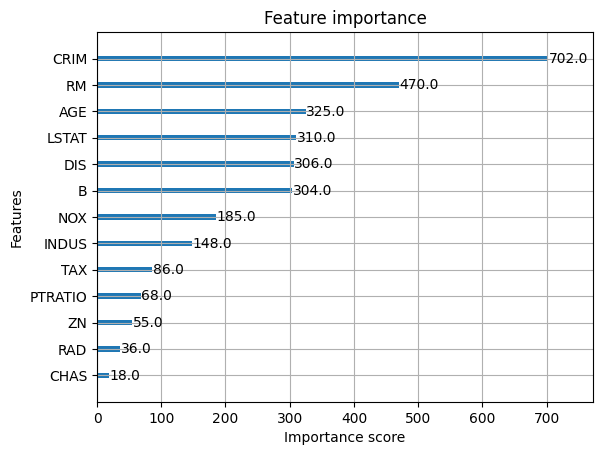

In [ ]:
# 모델 학습

# 모델 예측값 확인

# 평가지표 출력

# 변수 중요도 시각화


## **6. GridSearchCV**
- sklearn 패키지에는 파라메터 서칭 과정을 자동화 된 방식으로 진행 할 수 있도록 **GridSearchCV** 방법론을 제공합니다.  
- 기존 파라메터 서칭과 함께 **cross validation** 과정을 추가하여 데이터 분할에 강건한 모델을 선택할 수 있도록 제작 되었습니다.

### **6.1 K-Fold cross validation**  

<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/48.png">


In [ ]:
# 그리드 서치 import


In [ ]:
# 서칭 모델 정의

# 파라메터 그리드 딕셔너리 생성


그리드 서치 진행 시 필수 지정 파라메터  
- estimator : 모델 딕셔너리
- param_grid : 파라메터 딕셔너리
- scoring=None : 평가방법
- n_jobs=None : 학습에 사용할 컴퓨터 코어 갯수
- verbose=0 : 리포트 형식 0, 1, 2
- cv : Kfold cross validation

scoring 참고: https://scikit-learn.org/stable/modules/model_evaluation.html

In [ ]:
# grid 학습


In [ ]:
# 베스트 파라메터, 모델 확인


In [ ]:
# 그리드 모델 예측값 확인


In [ ]:
# 최적 모델 평가지표 출력


In [ ]:
# 베스트 모델의 변수 중요도 확인


## **7. SHAP value**
- **SHAP(SHapley Additive exPlanations)** 은 개별 데이터의 예측값에 대해 각 피처가 어떤 영향을 주었는지 수학적으로 계산하는 기법.
- 단순히 "어떤 피처가 중요한가"를 넘어, 그 피처가 예측값을 얼마나(+/-) 변화시켰는지를 설명
- SHAP은 게임 이론의 Shapley Value를 머신러닝에 이식  
여러 명의 선수(피처)가 팀(모델)을 이뤄 점수(예측값)를 냈을 때, 각 선수의 공헌도를 공정하게 배분하는 방식.
- 딥러닝 모델에도 적용 가능하며 최근 머신러닝 및 딥러닝 프로젝트에는 필수적으로 사용하는 하는 요소입니다.
- 모델이 복잡해짐에 따라 변수와 변수간 관계 분석이 어려워짐으로 인해 모델 출력결과값을 기반으로 한 변수중요도를 파악합니다.

$$f(x) = BaseValue + \sum_{i=1}^{M} \phi_i$$

> BaseValue ($E[f(X)]$): 모델에 아무런 정보를 주지 않았을 때의 평균 예측값입니다.  
> SHAP Value ($\phi_i$): 특정 피처 $i$가 추가됨으로써 베이스라인 대비 예측값이 변한 정도  
> Final Prediction ($f(x)$): 모든 피처의 SHAP Value를 베이스라인에 더하면 최종 예측값이 됩니다.

In [ ]:
# import shap


In [ ]:
# shap value 정의


In [ ]:
# shape value 호출


### **7.1 summary plot**
- 변수에 따른 모델의 전체적인 경향성을 파악하는 목적으로 사용
- 피처 중요도와 영향력의 방향(Positive/Negative)을 동시에 확인 가능함.

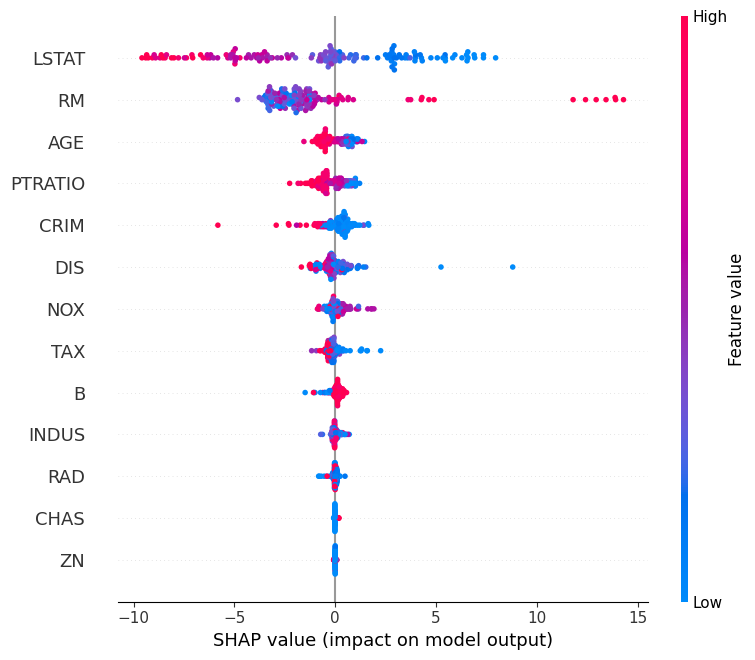

In [ ]:
# summary_plot


###**7.2 feature selection**

In [ ]:
# shap value 기준 변수 선택
